In [162]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [163]:
x=6*np.random.randn(200,1)-3
y=0.8 * x**2 +0.9*x +2+np.random.randn(200,1)

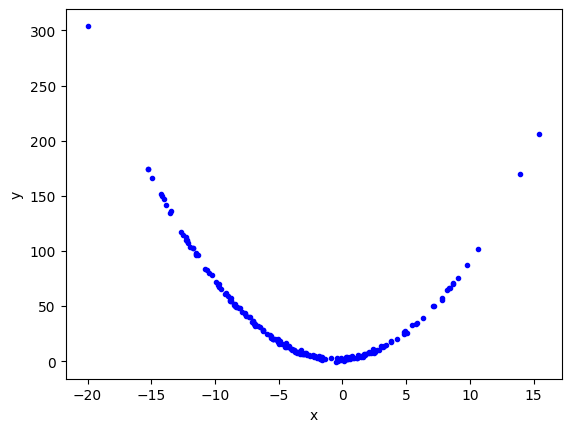

In [164]:
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [165]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [166]:
lr=LinearRegression()

In [167]:
lr.fit(x_train,y_train)

LinearRegression()

In [168]:
r2_score(y_test,lr.predict(x_test))

-0.3681498462941264

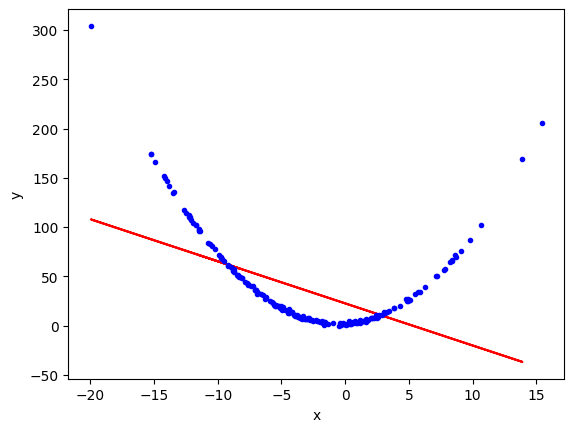

In [169]:
plt.plot(x_train,lr.predict(x_train),color='r')
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [170]:
#appli=ying polynomial linear regression
#degree=2

poly=PolynomialFeatures(degree=2)

x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)

In [171]:
print(x_train[0],x_train_trans[0])

[-8.3248028] [ 1.         -8.3248028  69.30234171]


                    include bias parameter
            if include_bias = false in Polynomialfeatures() it ignore x^0 / intercept_

In [172]:
lr=LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [173]:
r2_score(y_test,lr.predict(x_test_trans))

0.9994444697213661

In [174]:
lr.coef_,lr.intercept_

(array([[0.        , 0.9264784 , 0.80220207]]), array([2.12916904]))

In [175]:
x_new=np.linspace(-20,10,500).reshape(500,1)
x_new_poly=poly.transform(x_new)
y_new=lr.predict(x_new_poly)

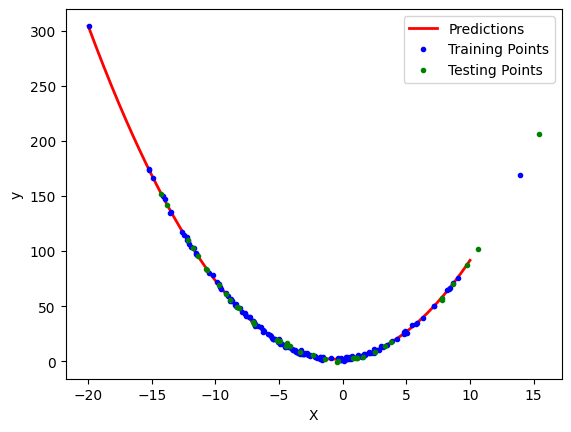

In [176]:
plt.plot(x_new,y_new,"r-",linewidth=2,label='Predictions')
plt.plot(x_train,y_train,'b.',label='Training Points')
plt.plot(x_test,y_test,'g.',label='Testing Points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

In [177]:
def polynomial_regression(degree):
    x_new=np.linspace(-20,10,100).reshape(100,1)
    x_new_poly=poly.transform(x_new)
    
    polybig_features=PolynomialFeatures(degree=degree,include_bias=False)
    std_scaler=StandardScaler()
    lin_reg=LinearRegression()
    polynomial_regression=Pipeline(
        [
            ("poly_features",polybig_features),
            ("std_scaler",std_scaler),
            ("lin_reg",lin_reg)
        ]
    )
    polynomial_regression.fit(x,y)
    y_newbig=polynomial_regression.predict(x_new)
    plt.plot(x_new,y_newbig,'r-',label='degree'+str(degree),linewidth=2)
    
    plt.plot(x_train,y_train,'b.',linewidth=3)
    plt.plot(x_test,y_test,'g.',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis([-20,15,0,300])
    plt.show()

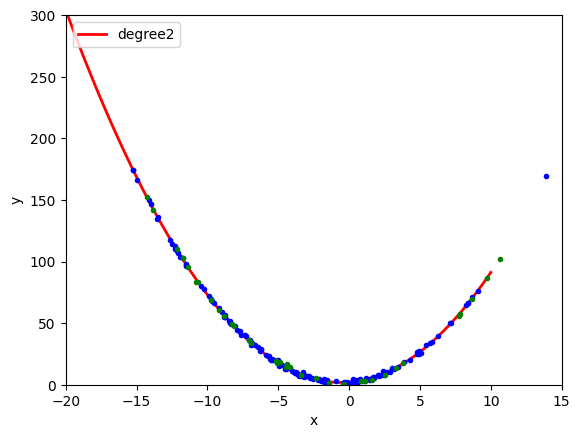

In [178]:
polynomial_regression(2)

                    3D Polynomial regression

In [179]:
x=7* np.random.randn(100,1).reshape(100,1)
y=7 * np.random.randn(100,1).reshape(100,1)
z=x**2 +y**2 +0.2*x + 0.2 * y +0.1 *x*y +2 + np.random.randn(100,1)

In [180]:
import plotly.express as px
df=px.data.iris()
fig=px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()

In [181]:
lr=LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)
x_input=np.linspace(x.min(),x.max(),10)
y_input=np.linspace(y.min(),y.max(),10)
xgrid,ygrid=np.meshgrid(x_input,y_input)
final=np.vstack((xgrid.ravel().reshape(1,100),ygrid.ravel().reshape(1,100))).T
z_final=lr.predict(final).reshape(10,10)

In [182]:
import plotly.graph_objects as go

fig=px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.show()

In [183]:
x_multi=np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [184]:
poly=PolynomialFeatures(degree=2)
x_multi_trans=poly.fit_transform(x_multi)

In [185]:
poly.n_features_in_,poly.n_output_features_,poly.powers_

(2,
 6,
 array([[0, 0],
        [1, 0],
        [0, 1],
        [2, 0],
        [1, 1],
        [0, 2]], dtype=int64))

In [186]:
x_multi_trans.shape

(100, 6)

In [187]:
lr=LinearRegression()
lr.fit(x_multi_trans,z)

LinearRegression()

In [188]:
x_test_multi=poly.transform(final)

In [189]:
z_final=lr.predict(x_multi_trans).reshape(10,10)

In [191]:
fig=px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.update_layout(scene=dict(
    zaxis=dict(range=[np.min(z_final), np.max(z_final)])
))

fig.show()